# GTEx tissue feature importance analysis (K-means binary + SHAP)

1. Load GTEx LV data, tissue metadata, and the saved K-means model
2. Derive binary tissue labels from K-means cluster assignments (majority-vote tissue per cluster)
3. For each tissue, train a binary RF classifier (tissue vs. rest) using k-means-derived labels
4. Compute SHAP values to explain which LVs drive each tissue
5. Downstream: specificity heatmap, trait associations, GO BP pathways

💡 **Environment:** `clamp-analyses`

In [163]:
import os
import pickle
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, adjusted_rand_score
import matplotlib.pyplot as plt
import seaborn as sns

from pyprojroot.here import here
import shap

import rpy2.robjects as ro
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import pandas2ri
readRDS = ro.r["readRDS"]

import csv
import re
import textwrap
import urllib.request
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
from itertools import groupby

np.random.seed(42)

# Settings

In [164]:
GLOBAL_SEED = 42
N_TOP_FEATURES = 10
CORRELATION_THRESHOLD = 0.8
MIN_CLUSTER_PURITY = 0.9
MIN_RF_ACCURACY = 0.9

# random forest hyperparameter grid
PARAM_GRID = {
    'n_estimators': [100, 300, 500, 1000],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
}

# Output

In [165]:
OUTPUT_DIR = here('output/gtex_feature_importance_kmeans_binary_shap')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {OUTPUT_DIR}")

Output directory: /home/msubirana/Documents/pivlab/clamp-analyses/output/gtex_feature_importance_kmeans_binary_shap


# Load data

In [166]:
# load .rds files from CLAMP with different priors
gtex_CLAMPfull_rds = readRDS(str(here('output/gtex/CLAMPfull.rds')))


def extract_B_matrix(rds_obj):
    B_matrix = rds_obj.rx2("B")
    with localconverter(ro.default_converter + pandas2ri.converter):
        B_values = ro.conversion.rpy2py(B_matrix)
    df = pd.DataFrame(
        data=B_values,
        index=B_matrix.rownames if B_matrix.rownames else None,
        columns=B_matrix.colnames if B_matrix.colnames else None,
    )
    return df

gtex_CLAMPfull = extract_B_matrix(gtex_CLAMPfull_rds)

lv_data = gtex_CLAMPfull
lv_data.head()

,GTEX-1117F-0226-SM-5GZZ7,GTEX-1117F-0426-SM-5EGHI,GTEX-1117F-0526-SM-5EGHJ,GTEX-1117F-0626-SM-5N9CS,GTEX-1117F-0726-SM-5GIEN,GTEX-1117F-1326-SM-5EGHH,GTEX-1117F-2426-SM-5EGGH,GTEX-1117F-2526-SM-5GZY6,GTEX-1117F-2826-SM-5GZXL,GTEX-1117F-2926-SM-5GZYI,...,GTEX-ZZPU-1126-SM-5N9CW,GTEX-ZZPU-1226-SM-5N9CK,GTEX-ZZPU-1326-SM-5GZWS,GTEX-ZZPU-1426-SM-5GZZ6,GTEX-ZZPU-1826-SM-5E43L,GTEX-ZZPU-2126-SM-5EGIU,GTEX-ZZPU-2226-SM-5EGIV,GTEX-ZZPU-2426-SM-5E44I,GTEX-ZZPU-2626-SM-5E45Y,GTEX-ZZPU-2726-SM-5NQ8O
LV1,-0.015950,0.000837,-0.004988,0.014039,-0.028191,0.084516,0.040783,-0.005818,0.000215,0.051014,...,-0.034783,-0.013994,-0.104900,-0.122868,0.010457,0.021119,0.004285,0.023583,-0.118818,0.010868
LV2,-0.066834,-0.022138,-0.062696,-0.060348,-0.087130,0.014613,-0.069380,0.102797,-0.048902,0.029582,...,-0.140538,-0.047281,-0.114984,-0.050550,-0.142226,-0.118534,0.101174,-0.150562,-0.130976,-0.111297
LV3,0.043647,-0.020761,0.000503,0.097614,0.127882,0.176253,0.025285,0.149440,-0.185211,0.049754,...,-0.137142,-0.073025,-0.048933,-0.072504,-0.212156,-0.167347,0.072479,-0.190934,-0.112331,-0.146610
LV4,-0.010623,-0.015625,-0.068182,-0.213239,-0.079228,-0.078269,-0.317992,0.101897,0.130456,0.202338,...,-0.086806,-0.117457,-0.055288,0.043466,-0.059416,-0.052044,0.060835,-0.089198,-0.008282,-0.059063
LV5,-0.093971,0.009481,-0.137962,0.025290,-0.013533,-0.023843,0.025453,0.050570,-0.124532,-0.062539,...,0.017702,-0.028076,-0.039394,-0.260858,-0.015830,0.039937,0.038509,-0.126627,0.011977,-0.081669


In [167]:
def extract_summary_matrix(rds_obj):
    summary_matrix = rds_obj.rx2("summary")
    with localconverter(ro.default_converter + pandas2ri.converter):
        summary_values = ro.conversion.rpy2py(summary_matrix)
    df = pd.DataFrame(
        data=summary_values,
        index=summary_matrix.rownames if summary_matrix.rownames else None,
        columns=summary_matrix.colnames if summary_matrix.colnames else None,
    )
    return df

gtex_CLAMPfull_summary = extract_summary_matrix(gtex_CLAMPfull_rds)
gtex_CLAMPfull_summary["pathway"] = gtex_CLAMPfull_summary["pathway"].str.replace("C2CP_", "", regex=False)

print(gtex_CLAMPfull_summary.shape)
gtex_CLAMPfull_summary.head()

(2377, 7)


,pathway,LV,AUC,p_value,FDR,npos,nneg
BP564,BP_Cardiac Muscle Cell Membrane Repolarization...,LV1,0.562442,0.372298,0.661192,2,21520
BP655,BP_Cellular Response to Corticosteroid Stimulu...,LV1,0.245748,0.907717,0.940998,2,21520
BP734,BP_Cellular Response to Prostaglandin Stimulus...,LV1,0.613929,0.276108,0.598202,2,21520
BP1562,BP_Lysosomal Membrane Organization (GO:0097212),LV1,0.870771,0.026516,0.146524,2,21520
BP2653,BP_Peptidyl-Threonine Dephosphorylation (GO:00...,LV1,0.740381,0.104871,0.336410,2,21520


In [168]:
path = here('data/gtex/GTEx_Analysis_v8_Annotations_SampleAttributesDS.txt')

gtex_meta = pd.read_csv(
    path,
    sep='\t',
    header=0,
    dtype=str,
    quoting=csv.QUOTE_NONE,
    engine='python',
    comment=None,
    keep_default_na=False,
    on_bad_lines='warn'
)

print(gtex_meta.shape)
gtex_meta.head()

(22951, 63)


,SAMPID,SMATSSCR,SMCENTER,SMPTHNTS,SMRIN,SMTS,SMTSD,SMUBRID,SMTSISCH,SMTSPAX,...,SME1ANTI,SMSPLTRD,SMBSMMRT,SME1SNSE,SME1PCTS,SMRRNART,SME1MPRT,SMNUM5CD,SMDPMPRT,SME2PCTS
0,GTEX-1117F-0003-SM-58Q7G,,B1,,,Blood,Whole Blood,0013756,1188,,...,,,,,,,,,,
1,GTEX-1117F-0003-SM-5DWSB,,B1,,,Blood,Whole Blood,0013756,1188,,...,,,,,,,,,,
2,GTEX-1117F-0003-SM-6WBT7,,B1,,,Blood,Whole Blood,0013756,1188,,...,,,,,,,,,,
3,GTEX-1117F-0011-R10a-SM-AHZ7F,,"B1, A1",,,Brain,Brain - Frontal Cortex (BA9),0009834,1193,,...,,,,,,,,,,
4,GTEX-1117F-0011-R10b-SM-CYKQ8,,"B1, A1",,7.2,Brain,Brain - Frontal Cortex (BA9),0009834,1193,,...,,,,,,,,,,


In [169]:
# transpose to get samples as rows, LVs as columns
lv_matrix = lv_data.T

# filter metadata to only include samples in LV matrix
meta_filtered = gtex_meta[gtex_meta['SAMPID'].isin(lv_matrix.index)].copy()
meta_filtered = meta_filtered.set_index('SAMPID')
meta_filtered = meta_filtered.loc[lv_matrix.index]

tissue_labels = meta_filtered['SMTSD']

print(f"Number of samples: {len(lv_matrix)}")
print(f"Number of LVs: {lv_matrix.shape[1]}")
print(f"Number of unique tissues: {tissue_labels.nunique()}")
print(f"\nTissue distribution:")
print(tissue_labels.value_counts().head())

Number of samples: 17382
Number of LVs: 289
Number of unique tissues: 54

Tissue distribution:
SMTSD
Muscle - Skeletal                 803
Whole Blood                       755
Skin - Sun Exposed (Lower leg)    701
Adipose - Subcutaneous            663
Artery - Tibial                   663
Name: count, dtype: int64


In [170]:
phenoplier_path = here('data/gtex/phenoplier/gtex-gls-summary-phenomexcan.tsv.gz')

phenoplier = pd.read_csv(
    phenoplier_path,
    sep="\t",
    compression="gzip",
    low_memory=False
)

print(phenoplier.shape)
print(phenoplier.columns.tolist())

(1668188, 5)
['phenotype', 'phenotype_desc', 'lv', 'pvalue', 'fdr']


# Load K-means model

Load the K-means model trained in `00_kmeans_clustering.ipynb`.
Cluster labels are used to derive binary tissue labels for each RF.

In [171]:
model_path = here('output/gtex/kmeans_models/gtex_CLAMPfull_kmeans_model.pkl')

with open(model_path, 'rb') as f:
    model_bundle = pickle.load(f)

km_model = model_bundle['model']
km_scaler = model_bundle['scaler']
best_k = model_bundle['best_k']
best_approach = model_bundle['best_approach']
saved_ari = model_bundle['ari']

print(f"K-means model: k={best_k}, approach={best_approach}, ARI={saved_ari:.4f}")

# apply the same preprocessing and get cluster assignments
if best_approach == 'scaled':
    X_km = km_scaler.transform(lv_matrix.astype(np.float32))
else:
    X_km = lv_matrix.values.astype(np.float32)

cluster_labels = km_model.predict(X_km)

# verify ARI matches
reproduced_ari = adjusted_rand_score(tissue_labels.values, cluster_labels)
print(f"Reproduced ARI: {reproduced_ari:.4f} (saved: {saved_ari:.4f})")

# map clusters to tissues (majority vote)
cluster_tissue_map = {}
cluster_tissue_purity = {}

for c in range(best_k):
    mask = cluster_labels == c
    cluster_tissues = tissue_labels[mask]
    dominant_tissue = cluster_tissues.value_counts().index[0]
    purity = cluster_tissues.value_counts().iloc[0] / len(cluster_tissues)
    cluster_tissue_map[c] = dominant_tissue
    cluster_tissue_purity[c] = purity

# group clusters by dominant tissue
tissue_to_clusters = defaultdict(list)
for c, tissue in cluster_tissue_map.items():
    tissue_to_clusters[tissue].append(c)

# cluster summary
cluster_summary = pd.DataFrame({
    'Cluster': range(best_k),
    'Dominant_Tissue': [cluster_tissue_map[c] for c in range(best_k)],
    'Purity': [cluster_tissue_purity[c] for c in range(best_k)],
    'Size': [np.sum(cluster_labels == c) for c in range(best_k)]
}).sort_values('Dominant_Tissue')

print(f"\nCluster summary ({best_k} clusters):")
display(cluster_summary)

# binary tissue labels derived from k-means (positive = sample in a cluster dominated by that tissue)
km_tissue_labels = pd.Series(
    [cluster_tissue_map[c] for c in cluster_labels],
    index=lv_matrix.index
)
print(f"\nK-means-derived tissue label distribution:")
print(km_tissue_labels.value_counts())

K-means model: k=48, approach=scaled, ARI=0.7307
Reproduced ARI: 0.6678 (saved: 0.7307)

Cluster summary (48 clusters):


,Cluster,Dominant_Tissue,Purity,Size
39,39,Adipose - Subcutaneous,0.775330,454
31,31,Adipose - Subcutaneous,0.643923,469
3,3,Adipose - Visceral (Omentum),0.858209,268
25,25,Adipose - Visceral (Omentum),0.889231,325
21,21,Adrenal Gland,1.000000,258
7,7,Artery - Aorta,1.000000,422
13,13,Artery - Coronary,0.889831,236
9,9,Artery - Tibial,0.987597,645
11,11,Brain - Cerebellum,0.533482,448
2,2,Brain - Cortex,0.349206,630



K-means-derived tissue label distribution:
Skin - Sun Exposed (Lower leg)               1068
Esophagus - Muscularis                        992
Adipose - Subcutaneous                        923
Muscle - Skeletal                             806
Whole Blood                                   754
Brain - Hippocampus                           689
Esophagus - Mucosa                            650
Thyroid                                       645
Artery - Tibial                               645
Brain - Cortex                                630
Nerve - Tibial                                619
Adipose - Visceral (Omentum)                  593
Lung                                          578
Colon - Sigmoid                               562
Cells - Cultured fibroblasts                  504
Brain - Hypothalamus                          501
Brain - Cerebellum                            448
Heart - Atrial Appendage                      426
Brain - Nucleus accumbens (basal ganglia)     426
Heart 

# LV correlation analysis

Before running feature importance, we need to check for multicollinearity among LVs.
Highly correlated features can affect SHAP importance interpretation.
Pearson correlation

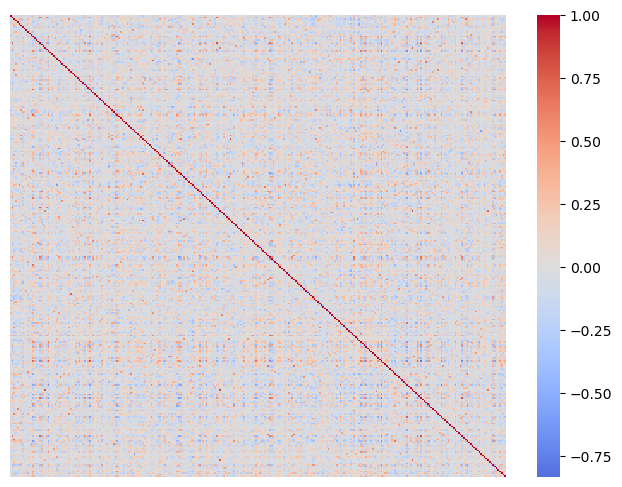

Number of highly correlated pairs (|r| > 0.9): 0


In [172]:
# correlation matrix
corr_matrix = lv_matrix.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0,
            xticklabels=False, yticklabels=False)
plt.show()

# find highly correlated pairs
high_corr_threshold = 0.9
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > high_corr_threshold:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

print(f"Number of highly correlated pairs (|r| > {high_corr_threshold}): {len(high_corr_pairs)}")

LVs independent

# Feature importance analysis (K-means binary + SHAP)

For each tissue (defined by k-means cluster majority vote), train a **binary RF**:
- Positive class (1): samples assigned to clusters whose dominant tissue is this tissue
- Negative class (0): all other samples

Uses nested cross-validation:
- Outer CV: unbiased performance estimation
- Inner CV: hyperparameter tuning

In [173]:
_files_exist = (
    (OUTPUT_DIR / "accuracy_summary.tsv").exists() and
    (OUTPUT_DIR / "all_shap_positive.tsv").exists() and
    (OUTPUT_DIR / "cumulative_importance.tsv").exists()
)
if _files_exist:
    print("results found, skipping feature importance and SHAP computation")
else:
    print("results not found, running feature importance and SHAP computation")

results not found, running feature importance and SHAP computation


In [ ]:
if not _files_exist:
    global_seed = GLOBAL_SEED

    param_distributions = {
        'n_estimators': [100, 300, 500, 1000],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
    }

    tissues = sorted(tissue_to_clusters.keys())
    tissues = [
        t for t in tissues
        if np.mean([cluster_tissue_purity[c] for c in tissue_to_clusters[t]]) >= MIN_CLUSTER_PURITY
    ]
    print(f"Tissues with purity >= {MIN_CLUSTER_PURITY}: {tissues}")

    accuracy_list = []
    shap_results_list = []
    cumulative_importance_list = []
    top5_lvs_by_tissue = {}

    (OUTPUT_DIR / "per_tissue").mkdir(parents=True, exist_ok=True)

    for i, tissue in enumerate(tissues):
        tissue_clusters = tissue_to_clusters[tissue]
        mean_purity = np.mean([cluster_tissue_purity[c] for c in tissue_clusters])

        print(f"[{i+1}/{len(tissues)}] {tissue} (clusters={tissue_clusters}, purity={mean_purity:.2f})")

        # binary label from k-means: 1 if sample's cluster belongs to this tissue
        y_binary = (km_tissue_labels == tissue).astype(int)

        n_pos = y_binary.sum()
        n_neg = (1 - y_binary).sum()
        imbalance_ratio = n_neg / n_pos if n_pos > 0 else float('inf')

        outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=global_seed + i)
        outer_test_scores = []
        best_params_list = []

        for outer_fold, (dev_idx, test_idx) in enumerate(outer_cv.split(lv_matrix, y_binary)):
            lv_data_dev = lv_matrix.iloc[dev_idx]
            y_dev = y_binary.iloc[dev_idx]
            lv_data_test = lv_matrix.iloc[test_idx]
            y_test = y_binary.iloc[test_idx]

            inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=global_seed + i)
            clf = RandomForestClassifier(random_state=global_seed + i, class_weight='balanced')
            random_search = RandomizedSearchCV(
                estimator=clf,
                param_distributions=param_distributions,
                n_iter=15,
                cv=inner_cv,
                scoring='balanced_accuracy',
                n_jobs=-1,
                random_state=global_seed + i
            )
            random_search.fit(lv_data_dev, y_dev)
            best_params_list.append(random_search.best_params_)

            final_model_outer = RandomForestClassifier(
                random_state=global_seed + i,
                class_weight='balanced',
                **random_search.best_params_
            )
            final_model_outer.fit(lv_data_dev, y_dev)
            y_pred = final_model_outer.predict(lv_data_test)
            outer_test_scores.append(balanced_accuracy_score(y_test, y_pred))

        best_fold_idx = np.argmax(outer_test_scores)
        final_params = best_params_list[best_fold_idx]

        print(f"  nested CV balanced accuracy: {np.mean(outer_test_scores):.4f} +/- {np.std(outer_test_scores):.4f}")

        # train final model on all data
        final_model = RandomForestClassifier(
            random_state=global_seed + i,
            class_weight='balanced',
            **final_params
        )
        final_model.fit(lv_matrix, y_binary)

        # SHAP analysis
        explainer = shap.TreeExplainer(final_model, data=lv_matrix, feature_perturbation="interventional")
        shap_explanation = explainer(lv_matrix)

        # extract SHAP values for positive class (tissue membership)
        shap_values_class1 = shap_explanation.values[..., 1]

        # average over samples that belong to this tissue's clusters
        tissue_mask = y_binary == 1
        shap_values_tissue_samples = shap_values_class1[tissue_mask]
        mean_shap_tissue = np.mean(shap_values_tissue_samples, axis=0)

        df_shap_all = pd.DataFrame({
            "Feature": lv_matrix.columns,
            "Mean_SHAP_Tissue": mean_shap_tissue
        })

        df_positive = df_shap_all[df_shap_all["Mean_SHAP_Tissue"] > 0].copy()
        df_positive = df_positive.sort_values("Mean_SHAP_Tissue", ascending=False).reset_index(drop=True)

        # cumulative importance
        n_features_needed = {}
        if len(df_positive) > 0:
            total_positive_shap = df_positive["Mean_SHAP_Tissue"].sum()
            df_positive["Cumulative_SHAP"] = df_positive["Mean_SHAP_Tissue"].cumsum()
            df_positive["Cumulative_Percent"] = (df_positive["Cumulative_SHAP"] / total_positive_shap) * 100
            df_positive["Rank"] = range(1, len(df_positive) + 1)

            for thresh in [50, 70, 80, 90, 95]:
                n_features_needed[thresh] = (df_positive["Cumulative_Percent"] >= thresh).idxmax() + 1

            df_cumulative = df_positive[["Feature", "Mean_SHAP_Tissue", "Cumulative_Percent", "Rank"]].copy()
            df_cumulative["Tissue"] = tissue
            cumulative_importance_list.append(df_cumulative)

        accuracy_list.append({
            "Tissue": tissue,
            "N_Clusters": len(tissue_clusters),
            "Mean_Purity": mean_purity,
            "Best_Test_Balanced_Accuracy": outer_test_scores[best_fold_idx],
            "Mean_CV_Accuracy": np.mean(outer_test_scores),
            "Std_CV_Accuracy": np.std(outer_test_scores),
            "Imbalance_Ratio": imbalance_ratio,
            "N_Positive_LVs": len(df_positive),
            "LVs_for_80pct": n_features_needed.get(80),
            "LVs_for_90pct": n_features_needed.get(90),
        })

        df_all_positive = df_positive.copy()
        df_all_positive["Tissue"] = tissue
        shap_results_list.append(df_all_positive)

        safe_name = tissue.replace(' ', '_').replace('/', '_')
        df_positive.to_csv(OUTPUT_DIR / "per_tissue" / f"shap_positive_{safe_name}.tsv", sep="\t", index=False)
        top5_lvs_by_tissue[tissue] = df_positive["Feature"].head(5).tolist()
        print(f"  top LVs: {top5_lvs_by_tissue[tissue]}")

    # compile results
    accuracy_df = pd.DataFrame(accuracy_list)
    shap_results_df = pd.concat(shap_results_list, ignore_index=True)
    cumulative_df = pd.concat(cumulative_importance_list, ignore_index=True)

    # filter by test accuracy before saving
    passing_tissues = accuracy_df[accuracy_df['Best_Test_Balanced_Accuracy'] >= MIN_RF_ACCURACY]['Tissue']
    accuracy_df = accuracy_df[accuracy_df['Tissue'].isin(passing_tissues)]
    shap_results_df = shap_results_df[shap_results_df['Tissue'].isin(passing_tissues)]
    cumulative_df = cumulative_df[cumulative_df['Tissue'].isin(passing_tissues)]
    print(f"Tissues passing accuracy >= {MIN_RF_ACCURACY}: {sorted(passing_tissues.tolist())}")

    accuracy_df.to_csv(OUTPUT_DIR / "accuracy_summary.tsv", sep="\t", index=False)
    shap_results_df.to_csv(OUTPUT_DIR / "all_shap_positive.tsv", sep="\t", index=False)
    cumulative_df.to_csv(OUTPUT_DIR / "cumulative_importance.tsv", sep="\t", index=False)
    print(f"\ndone. results saved to: {OUTPUT_DIR}")

Tissues with purity >= 0.9: ['Adrenal Gland', 'Artery - Aorta', 'Artery - Tibial', 'Breast - Mammary Tissue', 'Cells - Cultured fibroblasts', 'Cells - EBV-transformed lymphocytes', 'Colon - Transverse', 'Heart - Atrial Appendage', 'Heart - Left Ventricle', 'Liver', 'Lung', 'Minor Salivary Gland', 'Muscle - Skeletal', 'Nerve - Tibial', 'Ovary', 'Pancreas', 'Pituitary', 'Prostate', 'Small Intestine - Terminal Ileum', 'Spleen', 'Stomach', 'Testis', 'Thyroid', 'Whole Blood']
[1/24] Adrenal Gland (clusters=[21], purity=1.00)
  nested CV balanced accuracy: 1.0000 +/- 0.0000


100%|===================| 34691/34764 [05:22<00:00]        

  top LVs: ['LV132', 'LV251', 'LV136', 'LV158', 'LV20']
[2/24] Artery - Aorta (clusters=[7], purity=1.00)
  nested CV balanced accuracy: 0.9988 +/- 0.0024


100%|===================| 34596/34764 [02:12<00:00]        

  top LVs: ['LV145', 'LV85', 'LV155', 'LV204', 'LV233']
[3/24] Artery - Tibial (clusters=[9], purity=0.99)
  nested CV balanced accuracy: 0.9820 +/- 0.0067


...

  top LVs: ['LV11', 'LV224', 'LV155', 'LV186', 'LV214']
[8/24] Heart - Atrial Appendage (clusters=[10], purity=0.99)
  nested CV balanced accuracy: 0.9942 +/- 0.0064


100%|===================| 34711/34764 [03:48<00:00]        

  top LVs: ['LV269', 'LV13', 'LV61', 'LV199', 'LV145']
[9/24] Heart - Left Ventricle (clusters=[32], purity=0.98)


KeyboardInterrupt: 

: 

In [ ]:
accuracy_df = pd.read_csv(OUTPUT_DIR / "accuracy_summary.tsv", sep="\t")
shap_results_df = pd.read_csv(OUTPUT_DIR / "all_shap_positive.tsv", sep="\t")
cumulative_df = pd.read_csv(OUTPUT_DIR / "cumulative_importance.tsv", sep="\t")

In [ ]:
accuracy_df.sort_values(by='Mean_CV_Accuracy', ascending=False)

,Tissue,N_Clusters,Mean_Purity,Best_Test_Balanced_Accuracy,Mean_CV_Accuracy,Std_CV_Accuracy,Imbalance_Ratio,N_Positive_LVs,LVs_for_80pct,LVs_for_90pct
1,Adrenal Gland,1,1.000000,1.000000,1.000000,0.000000,66.372093,396,25,48
4,Brain,2,0.999772,1.000000,0.999966,0.000068,5.584091,395,35,68
2,Blood,2,0.880928,1.000000,0.999447,0.000881,13.920172,337,44,78
9,Muscle,1,0.996278,1.000000,0.998762,0.001517,20.565757,273,30,55
13,Skin,2,0.998845,1.000000,0.998060,0.001108,8.640599,401,52,94
14,Testis,1,1.000000,1.000000,0.997222,0.005556,47.149584,342,32,55
11,Pancreas,1,1.000000,1.000000,0.996970,0.003711,51.993902,334,39,69
15,Thyroid,1,0.590702,0.997727,0.996353,0.001118,14.845032,404,51,84
10,Nerve,1,0.993559,1.000000,0.995915,0.003640,26.990338,395,33,65
8,Lung,1,0.996540,1.000000,0.995675,0.002750,29.072664,396,29,59


In [ ]:
cumulative_df.head(40)

,Feature,Mean_SHAP_Tissue,Cumulative_Percent,Rank,Tissue
0,LV301,0.120819,13.346714,1,Adipose Tissue
1,LV263,0.066886,20.735498,2,Adipose Tissue
2,LV333,0.038457,24.983785,3,Adipose Tissue
3,LV230,0.035003,28.850524,4,Adipose Tissue
4,LV151,0.033472,32.548145,5,Adipose Tissue
5,LV319,0.026850,35.514207,6,Adipose Tissue
6,LV363,0.026786,38.473215,7,Adipose Tissue
7,LV386,0.026170,41.364168,8,Adipose Tissue
8,LV7,0.024915,44.116503,9,Adipose Tissue
9,LV310,0.019039,46.219667,10,Adipose Tissue
